In [3]:
import ase.io
import numpy as np
import matplotlib.pyplot

In [4]:
target_atoms = ase.io.read("/home/tuoping/odefed_mdgen//workdir_odefed_mdgen/data/MP_C_data/conventional.extxyz", ":")[0]
print(target_atoms.get_cell())

Cell([[5.37496088, 0.0, 0.0], [0.0, 4.98991554, 0.0], [-2.6874794400000006, 0.0, 7.76860372]])


In [5]:
target_atoms.wrap()
target_frac_pos = target_atoms.get_scaled_positions()
print(target_frac_pos)

[[0.4053525  0.25       0.310706  ]
 [0.45712727 0.         0.41425454]
 [0.0946905  0.25       0.18938101]
 [0.04291673 0.         0.08583296]
 [0.4053525  0.25       0.810706  ]
 [0.45712727 0.         0.91425454]
 [0.0946905  0.25       0.68938101]
 [0.04291673 0.         0.58583296]
 [0.4053525  0.75       0.310706  ]
 [0.45712727 0.5        0.41425454]
 [0.0946905  0.75       0.18938101]
 [0.04291673 0.5        0.08583296]
 [0.4053525  0.75       0.810706  ]
 [0.45712727 0.5        0.91425454]
 [0.0946905  0.75       0.68938101]
 [0.04291673 0.5        0.58583296]
 [0.9053525  0.25       0.310706  ]
 [0.95712727 0.         0.41425454]
 [0.5946905  0.25       0.18938101]
 [0.54291673 0.         0.08583296]
 [0.9053525  0.25       0.810706  ]
 [0.95712727 0.         0.91425454]
 [0.5946905  0.25       0.68938101]
 [0.54291673 0.         0.58583296]
 [0.9053525  0.75       0.310706  ]
 [0.95712727 0.5        0.41425454]
 [0.5946905  0.75       0.18938101]
 [0.54291673 0.5        0.08

In [6]:
from ase.visualize import view
view(target_atoms, viewer='ngl')

In [7]:
import torch
import scipy
import math

def lattice_polar_decompose(lattice: np.ndarray):
    assert lattice.ndim == 2
    A, U = np.linalg.eigh(lattice @ lattice.T)
    A, U = np.real(A), np.real(U)
    A = np.diag(np.log(A)) / 2
    S = U @ A @ U.T

    k = np.array(
        [
            S[0, 1],
            S[0, 2],
            S[1, 2],
            (S[0, 0] - S[1, 1]) / 2,
            (S[0, 0] + S[1, 1] - 2 * S[2, 2]) / 6,
            (S[0, 0] + S[1, 1] + S[2, 2]) / 3,
        ]
    )
    return k

def lattice_polar_build(k: np.ndarray):
    assert k.ndim == 1
    S = np.array(
        [
            [k[3] + k[4] + k[5], k[0], k[1]],
            [k[0], -k[3] + k[4] + k[5], k[2]],
            [k[1], k[2], -2 * k[4] + k[5]],
        ]
    )  # (3, 3)
    expS = scipy.linalg.expm(S)  # (3, 3)
    return expS


def decompose_symmetric_matrix(S: torch.Tensor):
    k0 = S[:, 0, 1]
    k1 = S[:, 0, 2]
    k2 = S[:, 1, 2]
    k3 = (S[:, 0, 0] - S[:, 1, 1]) / 2
    k4 = (S[:, 0, 0] + S[:, 1, 1] - 2 * S[:, 2, 2]) / 6
    k5 = (S[:, 0, 0] + S[:, 1, 1] + S[:, 2, 2]) / 3
    k = torch.vstack([k0, k1, k2, k3, k4, k5]).transpose(-1, -2)
    return k


@torch.no_grad()
def lattice_polar_decompose_torch(lattices: torch.Tensor):
    assert lattices.dim() == 3, "input must be batched lattices of shape (B,3,3)"
    A, U = torch.linalg.eigh(lattices @ lattices.transpose(-1,-2))  # J = L^T @ L
    # S = 1/2 U log(A) U^T
    A = torch.diag_embed(A.log()) / 2
    S = U @ A @ U.transpose(-1, -2)
    k = decompose_symmetric_matrix(S)
    return k

@torch.no_grad()
def lattice_polar_build_torch(k):
    assert k.dim() == 2, "input must be batched k of shape (B,6)"
    S0 = torch.stack([k[:, 3] + k[:, 4] + k[:, 5], k[:, 0], k[:, 1]], dim=1)  # (B, 3)
    S1 = torch.stack([k[:, 0], -k[:, 3] + k[:, 4] + k[:, 5], k[:, 2]], dim=1)  # (B, 3)
    S2 = torch.stack([k[:, 1], k[:, 2], -2 * k[:, 4] + k[:, 5]], dim=1)  # (B, 3)
    S = torch.stack([S0, S1, S2], dim=1)  # (B, 3, 3)
    expS = torch.matrix_exp(S)  # (B, 3, 3)
    return expS


def get_reciprocal_lattice_torch(L):
    V = torch.det(L)[:, None] + 1e-9  # (B, 1)
    a0 = L[:, 0, :]  # (B, 3)
    a1 = L[:, 1, :]
    a2 = L[:, 2, :]
    cross_a12 = torch.cross(a1, a2, dim=1)  # (B, 3)
    cross_a20 = torch.cross(a2, a0, dim=1)
    cross_a01 = torch.cross(a0, a1, dim=1)
    b0 = (2 * math.pi * cross_a12 / V)[:, None, :]  # (B, 1, 3)
    b1 = (2 * math.pi * cross_a20 / V)[:, None, :]  # (B, 1, 3)
    b2 = (2 * math.pi * cross_a01 / V)[:, None, :]  # (B, 1, 3)
    b = torch.cat([b0, b1, b2], dim=1)  # (B, 3, 3)
    return b

In [8]:
import torch
from ase import Atoms
target_cell = lattice_polar_decompose(target_atoms.get_cell())
_check_target_cell = lattice_polar_build(target_cell)
print(target_atoms.get_cell())
print(_check_target_cell)
_atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _check_target_cell,
        pbc=[True, True, True]
)

# print(target_atoms.get_cell_lengths_and_angles(), _atoms.get_cell_lengths_and_angles())
from ase.visualize import view
view(_atoms, viewer='ngl')

Cell([[5.37496088, 0.0, 0.0], [0.0, 4.98991554, 0.0], [-2.6874794400000006, 0.0, 7.76860372]])
[[ 5.26600627e+00  1.46809071e-16 -1.07674623e+00]
 [ 1.46809071e-16  4.98991554e+00  5.13449358e-16]
 [-1.07674623e+00  5.13449358e-16  8.14950103e+00]]


In [9]:
import torch
def sample_prior_cell():
    mu = torch.zeros(6)
    mu[-1] = 1.
    sigma = 0.1
    cell = torch.normal(mu, sigma)
    return cell
prior_cell = sample_prior_cell()
print(prior_cell)

tensor([ 0.0264,  0.0624,  0.0779, -0.1985, -0.1900,  0.9422])


In [10]:
t = torch.range(0,1,0.02)
print(t)

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
        0.9000, 0.9200, 0.9400, 0.9600, 0.9800, 1.0000])


/tmp/ipykernel_13335/2795543798.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  t = torch.range(0,1,0.02)


## Rectified flow of lattice

In [11]:
target_cell = torch.from_numpy(target_cell)
ut_cell = target_cell - prior_cell
xt_cell = t[:,None]*target_cell + (1-t[:,None])* prior_cell
print(xt_cell)
print(xt_cell.shape)

tensor([[ 2.6423e-02,  6.2367e-02,  7.7877e-02, -1.9847e-01, -1.8996e-01,
          9.4216e-01],
        [ 2.5894e-02,  5.7828e-02,  7.6319e-02, -1.9411e-01, -1.8922e-01,
          9.5891e-01],
        [ 2.5366e-02,  5.3290e-02,  7.4761e-02, -1.8976e-01, -1.8849e-01,
          9.7566e-01],
        [ 2.4837e-02,  4.8752e-02,  7.3204e-02, -1.8541e-01, -1.8775e-01,
          9.9241e-01],
        [ 2.4309e-02,  4.4213e-02,  7.1646e-02, -1.8106e-01, -1.8702e-01,
          1.0092e+00],
        [ 2.3781e-02,  3.9675e-02,  7.0089e-02, -1.7671e-01, -1.8628e-01,
          1.0259e+00],
        [ 2.3252e-02,  3.5137e-02,  6.8531e-02, -1.7236e-01, -1.8555e-01,
          1.0427e+00],
        [ 2.2724e-02,  3.0598e-02,  6.6974e-02, -1.6801e-01, -1.8482e-01,
          1.0594e+00],
        [ 2.2195e-02,  2.6060e-02,  6.5416e-02, -1.6366e-01, -1.8408e-01,
          1.0762e+00],
        [ 2.1667e-02,  2.1522e-02,  6.3859e-02, -1.5931e-01, -1.8335e-01,
          1.0929e+00],
        [ 2.1138e-02,  1.6984e

In [12]:
from ase import Atoms
_traj = []
for i in range(0, len(t), 10):
    _cell = lattice_polar_build(xt_cell[i].numpy())
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _cell,
        pbc=[True, True, True]
    )
    print(_atoms.get_cell_lengths_and_angles())
    _traj.append(_atoms)

[ 1.75401409  2.60969769  3.77884939 80.78206304 81.91777299 86.06732161]
[ 2.16669312  2.96693141  4.38479404 82.66771062 87.73855683 87.36237915]
[ 2.69667536  3.37529541  5.10365813 84.54093578 93.39341342 88.39425477]
[ 3.37755934  3.84244662  5.96037747 86.39342744 98.84696891 89.16732795]
[  4.25214273   4.37723821   6.98618838  88.21622661 104.07937126
  89.69579331]
[  5.37496088   4.98991554   8.22032539  90.         109.08260693
  90.        ]


/tmp/ipykernel_13335/2643556869.py:11: DeprecationWarning: Please use atoms.cell.cellpar() instead
  print(_atoms.get_cell_lengths_and_angles())


In [13]:
view(_traj[0], viewer='ngl')

In [33]:
view(_traj[-1], viewer='ngl')

## Lipman flow of lattice

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13335/1710916411.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$D=\sigma^2/2$")


Text(0, 0.5, '$D=\\sigma^2/2$')

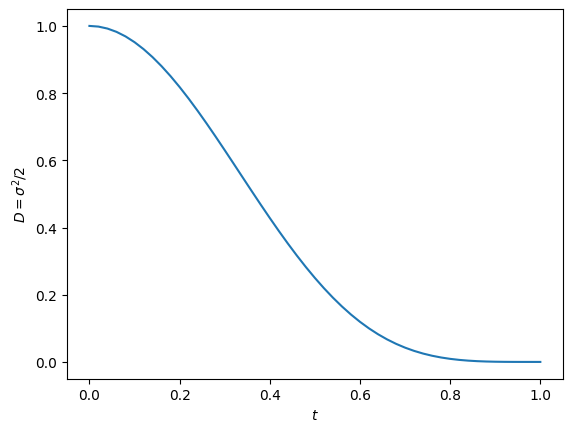

In [14]:
def expand_t_like_x(t, x):
    """Function to reshape time t to broadcastable dimension of x
    Args:
      t: [batch_dim,], time vector
      x: [batch_dim,...], data point
    """
    dims = [1] * (len(x.size()) - 1)
    t = t.view(t.size(0), *dims)
    return t


def compute_diffusion(x, t, norm=1.0):
    # return norm*torch.sin(np.pi * t)**2                 # increasing-decreasing
    return 0.25 * (norm * torch.cos(np.pi * t) + 1) ** 2     # decreasing

diffusion_t = compute_diffusion(prior_cell, t)
import matplotlib.pyplot as plt
plt.plot(t, diffusion_t[:])
plt.xlabel("$t$")
plt.ylabel("$D=\sigma^2/2$")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13335/4280418546.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")


Text(0, 0.5, '$\\sqrt{\\sigma^2*t(1-t)}$')

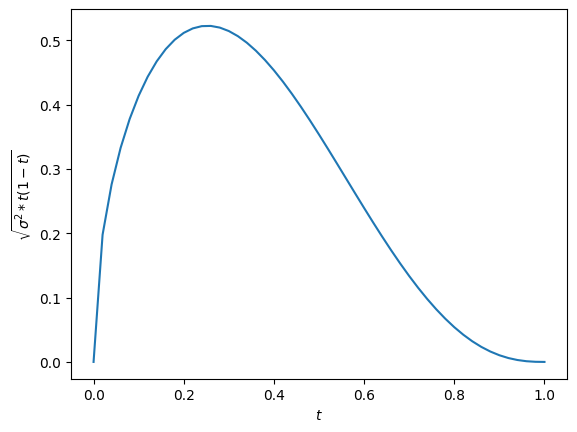

In [15]:
def compute_marginal_std(t, diffusion):
    """Compute the marginal standard deviation of the time-dependent density p_t"""
    return torch.sqrt(2*diffusion) * torch.sqrt(t*(1-t))

sigma_t = compute_marginal_std(t, diffusion_t)

plt.plot(t, sigma_t[:])
plt.xlabel("$t$")
plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")

In [16]:

# target_cell = torch.from_numpy(target_cell)
mu_t_cell = t[:,None]*target_cell + (1-t[:,None])* prior_cell
std_t = expand_t_like_x(sigma_t, mu_t_cell)

epsilon = torch.randn_like(mu_t_cell)
xt_cell = mu_t_cell + std_t*epsilon
print(xt_cell)
print(xt_cell.shape)

tensor([[ 2.6423e-02,  6.2367e-02,  7.7877e-02, -1.9847e-01, -1.8996e-01,
          9.4216e-01],
        [ 2.4445e-01,  3.3262e-01, -2.6505e-02, -2.8790e-01, -8.8453e-02,
          1.0575e+00],
        [ 1.9457e-01, -1.9563e-01,  7.3921e-03, -2.5054e-01, -2.5197e-01,
          6.8073e-01],
        [ 1.3700e-01,  2.4165e-01,  1.2913e-01,  2.0104e-02, -2.0394e-01,
          1.8562e+00],
        [-1.6405e-01, -3.9745e-01,  5.8143e-01,  1.6135e-01,  4.5084e-01,
          1.7736e+00],
        [ 3.0383e-01,  6.4128e-01, -1.5354e-01,  2.7292e-01, -6.0164e-01,
          1.2155e+00],
        [ 1.1033e-01,  5.8125e-02,  1.3867e-01,  5.4115e-02,  1.4677e-01,
          1.5016e+00],
        [-1.8929e-02,  3.0492e-01,  4.2016e-01, -1.1081e+00, -1.1126e-01,
          1.0424e+00],
        [ 3.4444e-01, -2.7398e-01,  6.1263e-01, -2.0762e-01, -1.0747e+00,
          1.7998e+00],
        [-1.0043e-01,  4.9446e-01, -3.3677e-01,  5.5974e-02,  3.6506e-01,
          1.0645e+00],
        [ 7.0758e-01,  5.9141e

In [17]:
from ase import Atoms
_traj = []
_traj_lattice_constants = []
for i in range(0, len(t), 10):
    _cell = lattice_polar_build(xt_cell[i].numpy())
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _cell,
        pbc=[True, True, True]
    )
    print(_atoms.get_cell_lengths_and_angles())
    _traj_lattice_constants.append(_atoms.get_cell_lengths_and_angles())
    _traj.append(_atoms)

[ 1.75401409  2.60969769  3.77884939 80.78206304 81.91777299 86.06732161]
[ 5.392033    7.21243113  8.05259485 34.49935536 24.97244632 20.00489698]
[ 15.58943703  12.01899408  14.66880759  70.04011572 135.80177155
  84.81339021]
[  2.22907241   2.24686528  13.32996273 120.20397125 114.95276525
  53.65684606]
[  4.38773451   4.31080733   6.22437569  86.81534351 105.93667922
  87.15335949]
[  5.37496088   4.98991554   8.22032539  90.         109.08260693
  90.        ]


/tmp/ipykernel_13335/1106380275.py:12: DeprecationWarning: Please use atoms.cell.cellpar() instead
  print(_atoms.get_cell_lengths_and_angles())
/tmp/ipykernel_13335/1106380275.py:13: DeprecationWarning: Please use atoms.cell.cellpar() instead
  _traj_lattice_constants.append(_atoms.get_cell_lengths_and_angles())


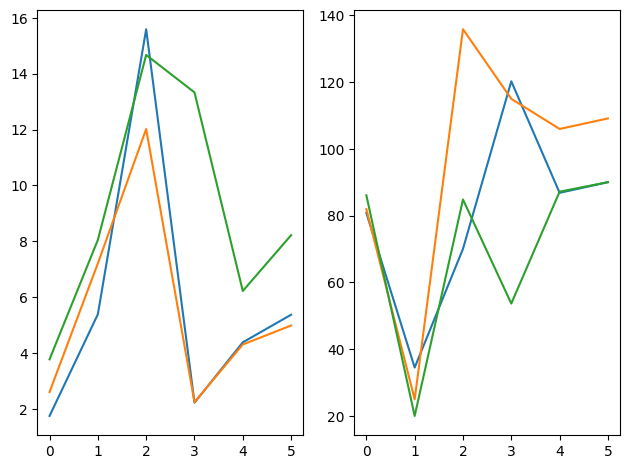

In [18]:
_traj_lattice_constants = np.array(_traj_lattice_constants)
plt.subplot(121)
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,0])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,1])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,2])
plt.subplot(122)
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,3])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,4])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,5])
plt.tight_layout()

In [19]:
view(_traj[5], viewer='ngl')

# Flow of fractional coordinates

In [20]:
def sample_prior_frac_pos(N):
    mu = torch.zeros(N*3)
    sigma = 1.
    pos = torch.normal(mu, sigma)
    return pos
prior_frac_pos = sample_prior_frac_pos(target_atoms.get_number_of_atoms())
print(prior_frac_pos)

tensor([ 0.7244, -1.7521, -0.7116,  0.5023, -1.2513, -1.3320,  0.1016, -1.6707,
        -1.1961, -1.4680,  0.6562, -0.9610,  0.6671,  1.9332,  0.6633,  1.1087,
         0.1889,  0.7853, -0.2739,  1.4284,  0.1040, -0.5222, -0.8466, -0.6002,
        -2.0838,  0.2632, -1.5790, -0.7690,  0.2849, -0.5241, -0.6349, -0.0048,
         0.5264, -0.1036, -1.4312, -0.0696,  1.7056,  0.0786, -1.9198, -0.2148,
         0.9395,  0.3834, -1.9132,  0.7329, -0.8603,  0.3691,  0.9134,  0.0257,
         0.8846,  0.4078, -1.2213,  1.7306,  1.6679,  1.2573, -0.3699,  0.1058,
        -1.0785, -0.1686,  0.7917, -0.4845, -0.4450, -0.2607,  0.7207,  0.7040,
        -0.3151,  1.0499, -0.5340, -1.8124,  2.0532, -0.0614,  0.6982,  0.4874,
         0.7569, -0.2140,  0.2011, -0.7617, -1.1105, -1.6864,  0.0740, -0.2362,
        -1.0244, -0.0451, -1.3055, -0.8264,  1.1443, -0.0079, -0.4084, -0.4397,
        -0.7969,  0.8792,  0.3462, -0.2768, -0.0724,  0.7324, -1.7213,  1.1807])


/tmp/ipykernel_13335/3053665412.py:6: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  prior_frac_pos = sample_prior_frac_pos(target_atoms.get_number_of_atoms())


In [21]:
def wrap_frac_pos(F):
    return F-(F).to(int)
target_frac_pos = torch.from_numpy(target_frac_pos)
prior_frac_pos = wrap_frac_pos(prior_frac_pos.reshape(-1,3))

## Rectified flow

In [22]:

xt_frac_pos = (prior_frac_pos[None,:,:] + t[:,None,None]*(wrap_frac_pos(target_frac_pos - prior_frac_pos - 0.5)[None,:,:] - 0.5))
print(xt_frac_pos)
print(xt_frac_pos.shape)

tensor([[[ 0.7244, -0.7521, -0.7116],
         [ 0.5023, -0.2513, -0.3320],
         [ 0.1016, -0.6707, -0.1961],
         ...,
         [-0.4397, -0.7969,  0.8792],
         [ 0.3462, -0.2768, -0.0724],
         [ 0.7324, -0.7213,  0.1807]],

        [[ 0.6980, -0.7521, -0.7111],
         [ 0.4814, -0.2663, -0.3371],
         [ 0.0815, -0.6722, -0.2084],
         ...,
         [-0.4317, -0.7910,  0.8599],
         [ 0.3312, -0.2763, -0.0771],
         [ 0.7086, -0.7169,  0.1688]],

        [[ 0.6717, -0.7520, -0.7107],
         [ 0.4605, -0.2813, -0.3422],
         [ 0.0614, -0.6738, -0.2206],
         ...,
         [-0.4238, -0.7850,  0.8406],
         [ 0.3162, -0.2758, -0.0819],
         [ 0.6848, -0.7125,  0.1569]],

        ...,

        [[-0.5419, -0.7501, -0.6902],
         [-0.5011, -0.9701, -0.5756],
         [-0.8650, -0.7468, -0.7860],
         ...,
         [-0.0587, -0.5119, -0.0471],
         [-0.3752, -0.2511, -0.3011],
         [-0.4095, -0.5089, -0.3904]],

        [[

In [23]:
_traj = []
for i in range(0, len(t), 10):
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = xt_frac_pos[i].numpy(),
        cell = target_atoms.get_cell(),
        pbc=[True,True,True]
    )
    _atoms.wrap()
    _traj.append(_atoms)

In [24]:
view(_traj[3], viewer='ngl')

In [25]:
view(_traj[5], viewer='ngl')

## Lipman flow

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13335/1445051594.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$D=\sigma^2/2$")


Text(0, 0.5, '$D=\\sigma^2/2$')

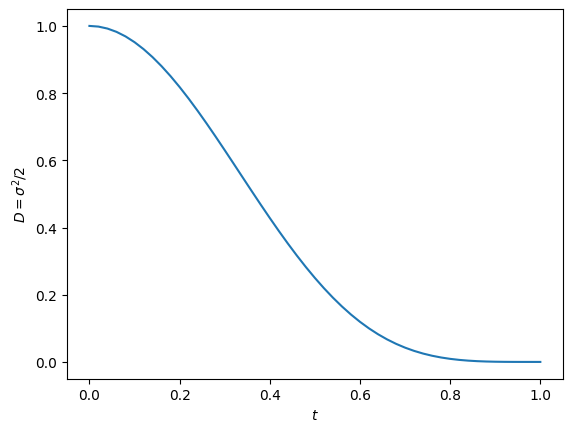

In [26]:
def expand_t_like_x(t, x):
    """Function to reshape time t to broadcastable dimension of x
    Args:
      t: [batch_dim,], time vector
      x: [batch_dim,...], data point
    """
    dims = [1] * (len(x.size()) - 1)
    t = t.view(t.size(0), *dims)
    return t


def compute_diffusion(x, t, norm=1.0):
    # return norm*torch.sin(np.pi * t)**2                 # increasing-decreasing
    return 0.25 * (norm * torch.cos(np.pi * t) + 1) ** 2     # decreasing

diffusion_t = compute_diffusion(prior_frac_pos, t)
import matplotlib.pyplot as plt
plt.plot(t, diffusion_t[:])
plt.xlabel("$t$")
plt.ylabel("$D=\sigma^2/2$")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_13335/4280418546.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")


Text(0, 0.5, '$\\sqrt{\\sigma^2*t(1-t)}$')

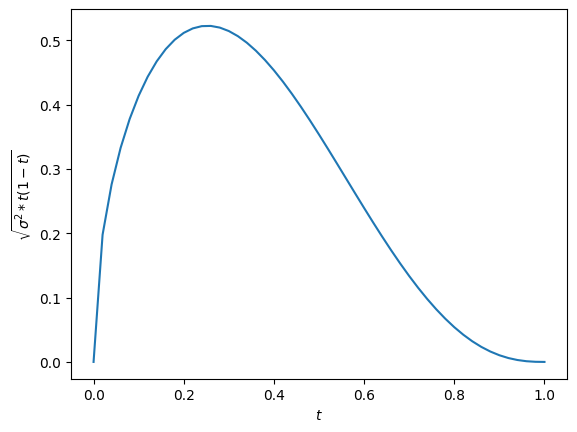

In [27]:
def compute_marginal_std(t, diffusion):
    """Compute the marginal standard deviation of the time-dependent density p_t"""
    return torch.sqrt(2*diffusion) * torch.sqrt(t*(1-t))

sigma_t = compute_marginal_std(t, diffusion_t)

plt.plot(t, sigma_t[:])
plt.xlabel("$t$")
plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")

In [28]:
def ewald_wrap_frac_pos(F):
    pass

In [29]:

mu_t_frac_pos = (prior_frac_pos[None,:,:] + t[:,None,None]*(wrap_frac_pos(target_frac_pos - prior_frac_pos - 0.5)[None,:,:] - 0.5))
std_t = expand_t_like_x(sigma_t, mu_t_frac_pos)

epsilon = torch.randn_like(mu_t_frac_pos)
xt_frac_pos = mu_t_frac_pos + std_t*epsilon
print(xt_frac_pos)
print(xt_frac_pos.shape)

tensor([[[ 0.7244, -0.7521, -0.7116],
         [ 0.5023, -0.2513, -0.3320],
         [ 0.1016, -0.6707, -0.1961],
         ...,
         [-0.4397, -0.7969,  0.8792],
         [ 0.3462, -0.2768, -0.0724],
         [ 0.7324, -0.7213,  0.1807]],

        [[ 0.7351, -0.3335, -0.3847],
         [ 0.7691, -0.7810,  0.2406],
         [ 0.2920, -0.7456, -0.3924],
         ...,
         [-0.2955, -0.9682,  0.8792],
         [ 0.2087, -0.0193,  0.1662],
         [ 0.6236, -0.7083,  0.3848]],

        [[ 0.4811, -0.6939, -0.7700],
         [ 0.8416, -0.1320, -0.6316],
         [-0.0928, -0.4808, -0.0243],
         ...,
         [-0.4713, -1.2011,  0.9916],
         [ 0.1393, -0.2554, -0.0516],
         [ 0.3160, -0.7713, -0.0604]],

        ...,

        [[-0.5419, -0.7500, -0.6899],
         [-0.5019, -0.9698, -0.5764],
         [-0.8665, -0.7476, -0.7864],
         ...,
         [-0.0577, -0.5129, -0.0465],
         [-0.3751, -0.2517, -0.3027],
         [-0.4097, -0.5095, -0.3890]],

        [[

In [30]:
_traj = []
for i in range(0, len(t), 10):
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = xt_frac_pos[i].numpy(),
        cell = target_atoms.get_cell(),
        pbc=[True,True,True]
    )
    # _atoms.wrap()
    _traj.append(_atoms)

In [31]:
view(_traj[3], viewer='ngl')

In [32]:
view(_traj[5], viewer='ngl')